In [131]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
device = torch.device("cpu")
print("Используемое устройство:", device)

Используемое устройство: cpu


In [132]:
torch.manual_seed(0)       
def f(x):
    return (torch.sin(x) + torch.sin(5 * x)).to(device)
    
def get_batch(n=500):
    x = (torch.rand(n, 1) * 2 - 1) * 2 * np.pi
    return (x).to(device), (f(x)).to(device)

In [133]:
model = nn.Sequential(
    nn.Linear(1, 256), nn.Tanh(),
    nn.Linear(256, 256), nn.Tanh(),
    nn.Linear(256, 1),
).to(device)


In [134]:
print(model)

x, y = get_batch()
h = x
print("вход".ljust(10), tuple(h.shape))
for layer in model:
    h = layer(h)
    print(layer.__class__.__name__.ljust(10), tuple(h.shape))

Sequential(
  (0): Linear(in_features=1, out_features=256, bias=True)
  (1): Tanh()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): Tanh()
  (4): Linear(in_features=256, out_features=1, bias=True)
)
вход       (500, 1)
Linear     (500, 256)
Tanh       (500, 256)
Linear     (500, 256)
Tanh       (500, 256)
Linear     (500, 1)


In [135]:
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

x_plot = torch.linspace(-2 * np.pi, 2 * np.pi, 1000).reshape(-1, 1)
show_epochs = [500, 2000, 3000]
snapshots = {}

for epoch in range(1, 3001):
    x, y = get_batch()
    loss = loss_fn(model(x), y)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if epoch in show_epochs:
        with torch.no_grad():
            snapshots[epoch] = model(x_plot)
        print(epoch, loss.item())

500 0.5107792615890503
2000 0.23868614435195923
3000 0.1202847808599472


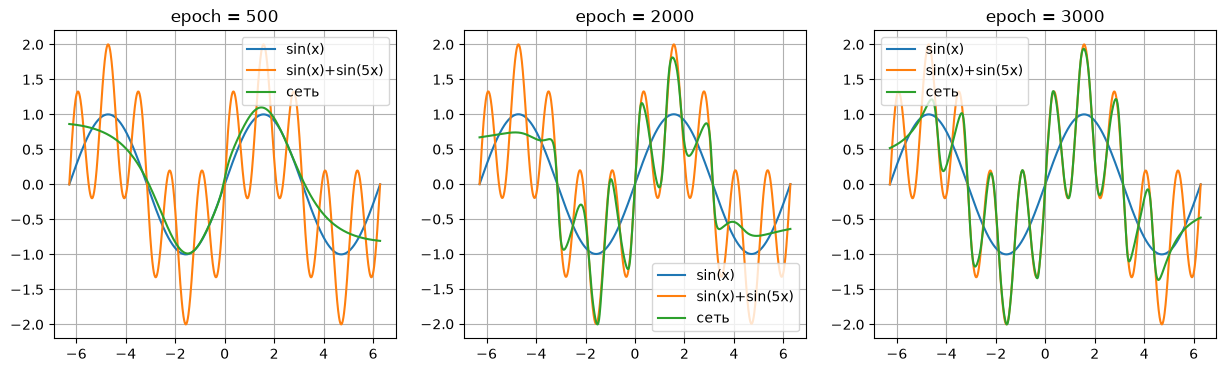

In [136]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ep in zip(axes, show_epochs):
    ax.plot(x_plot, torch.sin(x_plot), label="sin(x)")
    ax.plot(x_plot, f(x_plot), label="sin(x)+sin(5x)")
    ax.plot(x_plot, snapshots[ep], label="сеть")
    ax.set_title(f"epoch = {ep}")
    ax.legend()
    ax.grid(True)
plt.show()
 

In [137]:
class FourierFeatureEmbedding(nn.Module):
    def __init__(self, in_dim, mapping_size, scale=10.0):
        super().__init__()
        self.B = torch.randn(in_dim, mapping_size) * scale * 2 * torch.pi

    def forward(self, v):
        proj = torch.matmul(v, self.B)
        return torch.cat([torch.cos(proj), torch.sin(proj)], dim=-1)


torch.manual_seed(0)
model_f = nn.Sequential(
    FourierFeatureEmbedding(1, 128, scale=10.0),
    nn.Linear(256, 256), nn.Tanh(),
    nn.Linear(256, 1),
)
print(model_f)

x, y = get_batch()
h = x
print("вход".ljust(24), tuple(h.shape))
for layer in model_f:
    h = layer(h)
    print(layer.__class__.__name__.ljust(24), tuple(h.shape))

Sequential(
  (0): FourierFeatureEmbedding()
  (1): Linear(in_features=256, out_features=256, bias=True)
  (2): Tanh()
  (3): Linear(in_features=256, out_features=1, bias=True)
)
вход                     (500, 1)
FourierFeatureEmbedding  (500, 256)
Linear                   (500, 256)
Tanh                     (500, 256)
Linear                   (500, 1)


In [138]:
opt_f = torch.optim.Adam(model_f.parameters(), lr=1e-3)

for epoch in range(1, 201):
    x, y = get_batch()
    loss = loss_fn(model_f(x), y)
    opt_f.zero_grad()
    loss.backward()
    opt_f.step()
    if epoch % 50 == 0:
        print(epoch, loss.item())

50 0.5454778075218201
100 0.2031070590019226
150 0.028998319059610367
200 0.0028344346210360527


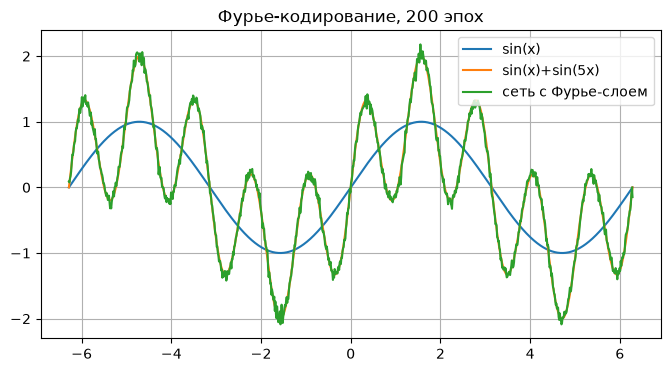

In [139]:
with torch.no_grad():
    pred_f = model_f(x_plot)

plt.figure(figsize=(8, 4))
plt.plot(x_plot, torch.sin(x_plot), label="sin(x)")
plt.plot(x_plot, f(x_plot), label="sin(x)+sin(5x)")
plt.plot(x_plot, pred_f, label="сеть с Фурье-слоем")
plt.title("Фурье-кодирование, 200 эпох")
plt.legend()
plt.grid(True)
plt.show()

In [140]:
torch.manual_seed(0)
model_f2 = nn.Sequential(
    FourierFeatureEmbedding(1, 128, scale=10.0),
    nn.Linear(256, 256),
    nn.Linear(256, 1),
)
print(model_f2)

x, y = get_batch()
h = x
print("вход".ljust(24), tuple(h.shape))
for layer in model_f2:
    h = layer(h)
    print(layer.__class__.__name__.ljust(24), tuple(h.shape))

Sequential(
  (0): FourierFeatureEmbedding()
  (1): Linear(in_features=256, out_features=256, bias=True)
  (2): Linear(in_features=256, out_features=1, bias=True)
)
вход                     (500, 1)
FourierFeatureEmbedding  (500, 256)
Linear                   (500, 256)
Linear                   (500, 1)


50 0.6429072618484497
100 0.4677772521972656
150 0.4798038899898529
200 0.4860837757587433


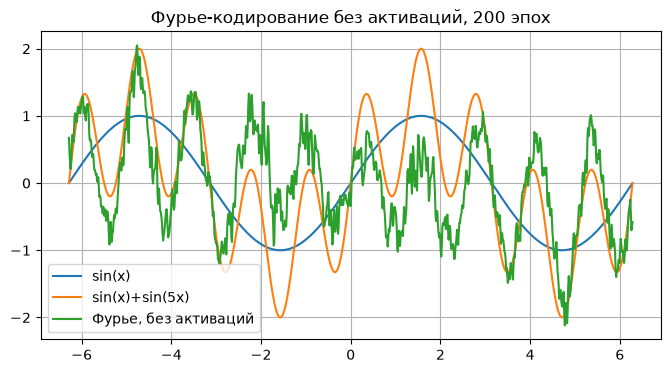

In [141]:
opt_f2 = torch.optim.Adam(model_f2.parameters(), lr=1e-3)

for epoch in range(1, 201):
    x, y = get_batch()
    loss = loss_fn(model_f2(x), y)
    opt_f2.zero_grad()
    loss.backward()
    opt_f2.step()
    if epoch % 50 == 0:
        print(epoch, loss.item())

with torch.no_grad():
    pred_f2 = model_f2(x_plot)

plt.figure(figsize=(8, 4))
plt.plot(x_plot, torch.sin(x_plot), label="sin(x)")
plt.plot(x_plot, f(x_plot), label="sin(x)+sin(5x)")
plt.plot(x_plot, pred_f2, label="Фурье, без активаций")
plt.title("Фурье-кодирование без активаций, 200 эпох")
plt.legend()
plt.grid(True)
plt.show()